# 1. How big is the problem, and where do we lose people?

Questions 1 and 2 of the project ([questions](../docs/questions.md)).

Everything here runs on the DuckDB database that `src/build_db.py` builds.
Churn means the membership lapsed for more than 30 days, with billing gaps
excluded. The rules are in the [data notes](../docs/data_notes.md).

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)  # the daily-logs view reads files by relative path
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pandas as pd
from IPython.display import display

import charts
from analysis import connect, km, survival_at

charts.use_style()
pd.set_option("display.max_columns", 20)
con = connect()

## Q1. Paying subscribers, month by month

`marts.monthly_subscribers` counts paying subscribers only: from their first
payment to the end of the subscription. 2015 is a warm-up year, because
anyone who was already subscribed before January 2015 shows up as "new" on
their first transaction in the data. So the view starts in January 2016.

In [2]:
bridge = con.sql("""
    SELECT month, subscribers_start, new_subscribers, returning_subscribers,
           churned, subscribers_end, churn_rate, revenue_per_subscriber
    FROM marts.monthly_subscribers
    WHERE month >= DATE '2016-01-01'
""").df()

display(bridge.assign(
    month=bridge.month.dt.strftime("%b %Y"),
    churn_rate=(100 * bridge.churn_rate).round(2),
    revenue_per_subscriber=bridge.revenue_per_subscriber.round(),
).set_index("month"))

growth = bridge.subscribers_end.iloc[-1] / bridge.subscribers_start.iloc[0] - 1
h1 = bridge[bridge.month < "2016-07-01"].new_subscribers.mean()
h2 = bridge[(bridge.month >= "2016-07-01") & (bridge.month < "2017-01-01")].new_subscribers.mean()
print(f"Subscribers {bridge.subscribers_start.iloc[0]:,} -> {bridge.subscribers_end.iloc[-1]:,} ({100 * growth:+.0f}%)")
print(f"New subscribers per month: {h1:,.0f} in H1 2016, {h2:,.0f} in H2 2016, "
      f"{bridge[bridge.month >= '2017-01-01'].new_subscribers.mean():,.0f} in Jan-Feb 2017")
print(f"Churned per month since Jul 2016: {bridge[bridge.month >= '2016-07-01'].churned.min():,} "
      f"to {bridge[bridge.month >= '2016-07-01'].churned.max():,}")

,subscribers_start,new_subscribers,returning_subscribers,churned,subscribers_end,churn_rate,revenue_per_subscriber
month,,,,,,,
Jan 2016,903962,76538,15333,32861,962972,3.64,142.0
Feb 2016,962972,60745,12935,56486,980166,5.87,127.0
Mar 2016,980166,50265,12409,50601,992239,5.16,121.0
Apr 2016,992239,29153,11372,37484,995280,3.78,120.0
May 2016,995280,36306,11494,34521,1008559,3.47,119.0
Jun 2016,1008559,39018,13006,32839,1027744,3.26,118.0
Jul 2016,1027744,50208,27375,33084,1072243,3.22,130.0
Aug 2016,1072243,44482,14190,35091,1095824,3.27,130.0
Sep 2016,1095824,33198,13313,37190,1105145,3.39,129.0


Subscribers 903,962 -> 1,176,455 (+30%)
New subscribers per month: 48,671 in H1 2016, 40,140 in H2 2016, 37,428 in Jan-Feb 2017
Churned per month since Jul 2016: 33,084 to 42,670


PosixPath('/Users/artemzadvoryanskiy/Documents/portfolio/kkbox-subscription-analytics/docs/img/01_monthly_flows.png')

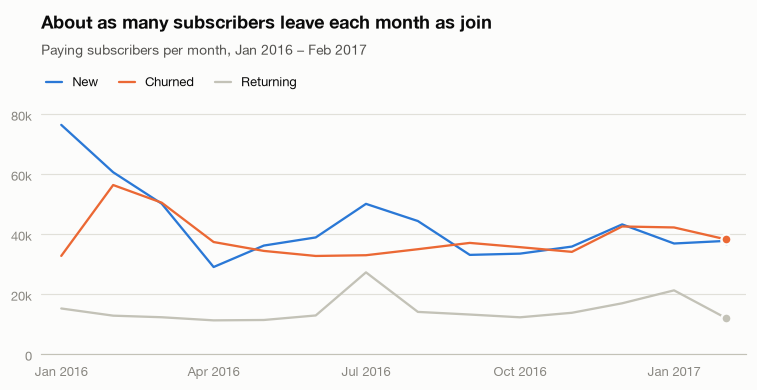

In [3]:
fig, ax = charts.figure()
k = 1000
ax.set_xlim(bridge.month.iloc[0] - pd.Timedelta(days=12), bridge.month.iloc[-1] + pd.Timedelta(days=12))
ax.set_ylim(0, 85)
h_new = charts.line(ax, bridge.month, bridge.new_subscribers / k, charts.BLUE, "New")
h_churn = charts.line(ax, bridge.month, bridge.churned / k, charts.ORANGE, "Churned")
h_ret = charts.line(ax, bridge.month, bridge.returning_subscribers / k, charts.GRAY, "Returning")
ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}k" if v else "0"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
charts.legend(ax, [(h_new, "New"), (h_churn, "Churned"), (h_ret, "Returning")])
charts.titles(fig, ax, "About as many subscribers leave each month as join",
              "Paying subscribers per month, Jan 2016 – Feb 2017")
charts.save(fig, "01_monthly_flows.png")

**What it says.** The base grew by 30%, but churn (33–43k a month since mid-2016)
runs at about the level of new subscribers, and new subscribers have slowed down.
The February 2016 peak is partly a batch of dormant subscriptions on one payment
method that all ended on 25 February (details in the findings).

## Q2. The lifecycle of a new subscriber

New users only: registered from 2015 on, so their whole history is visible.

### Free trials

In [4]:
firsts = con.sql("""
    SELECT s.*, u.channel
    FROM core.subscriptions AS s
    JOIN core.users AS u USING (user_id)
    WHERE s.subscription_number = 1 AND u.registered_in_window
""")
display(con.sql("""
    SELECT CASE WHEN started_with_trial THEN 'free trial' ELSE 'paid from day 1' END AS first_subscription,
           count(*) AS users,
           round(100 * avg(is_paid::INT), 1) AS pct_ever_paid
    FROM firsts GROUP BY 1
""").df())
display(con.sql("""
    SELECT channel, count(*) AS trials, round(100 * avg(is_paid::INT), 1) AS pct_converted
    FROM firsts
    WHERE started_with_trial AND (is_paid OR status = 'churned')
    GROUP BY 1 HAVING count(*) > 100 ORDER BY trials DESC
""").df())

,first_subscription,users,pct_ever_paid
0,paid from day 1,693759,92.3
1,free trial,223949,4.4


,channel,trials,pct_converted
0,channel 4,141071,2.3
1,channel 3,49468,6.3
2,channel 9,33357,10.7


### Survival from the first payment

Kaplan-Meier, so subscriptions still running when the data ends count for as
long as they were observed. "Month N" is 30·N + 15 days after the first
payment: past the N-th renewal date plus a little slack.

In [5]:
subs = con.sql("""
    SELECT s.started_with_trial,
           CASE WHEN s.first_paid_plan_days <= 31 THEN 'monthly' ELSE '3-12 months' END AS first_plan,
           least(s.end_date, DATE '2017-03-31') - s.first_payment_date AS days,
           (s.status = 'churned')::INT AS churned
    FROM core.subscriptions AS s
    JOIN core.users AS u USING (user_id)
    WHERE s.paid_number = 1 AND u.registered_in_window AND s.end_date >= s.first_payment_date
""").df()

MONTHS = [1, 2, 3, 6, 12, 18]
groups = {
    "all new subscribers": subs,
    "free trial first": subs[subs.started_with_trial],
    "paid from day 1": subs[~subs.started_with_trial],
    "monthly first plan": subs[subs.first_plan == "monthly"],
    "3-12 month first plan": subs[subs.first_plan == "3-12 months"],
}
curves = {name: km(g.days.values, g.churned.values) for name, g in groups.items()}
survival = pd.DataFrame(
    {name: [len(groups[name])] + [round(100 * survival_at(c, 30 * m + 15), 1) for m in MONTHS]
     for name, c in curves.items()},
    index=["subscriptions"] + [f"month {m}" for m in MONTHS],
).T
display(survival)

,subscriptions,month 1,month 2,month 3,month 6,month 12,month 18
all new subscribers,661181.0,88.6,84.4,81.0,74.8,65.3,57.7
free trial first,10320.0,78.4,71.6,66.5,57.4,45.3,34.8
paid from day 1,650861.0,88.8,84.6,81.3,75.0,65.6,58.0
monthly first plan,588389.0,87.2,82.5,79.5,73.6,64.5,58.5
3-12 month first plan,72792.0,99.9,99.5,93.7,84.4,71.1,50.4


In [6]:
all_curve = curves["all new subscribers"]
hazard = []
prev = 1.0
for m in range(1, 13):
    cur = survival_at(all_curve, 30 * m + 15)
    hazard.append(100 * (1 - cur / prev))
    prev = cur
hazard = pd.Series(hazard, index=range(1, 13), name="pct_leaving_that_month")
display(hazard.round(1).to_frame().T)

,1,2,3,4,5,6,7,8,9,10,11,12
pct_leaving_that_month,11.4,4.8,4.0,2.8,2.3,2.9,3.0,2.0,1.7,1.7,1.6,3.4


PosixPath('/Users/artemzadvoryanskiy/Documents/portfolio/kkbox-subscription-analytics/docs/img/01_first_renewal.png')

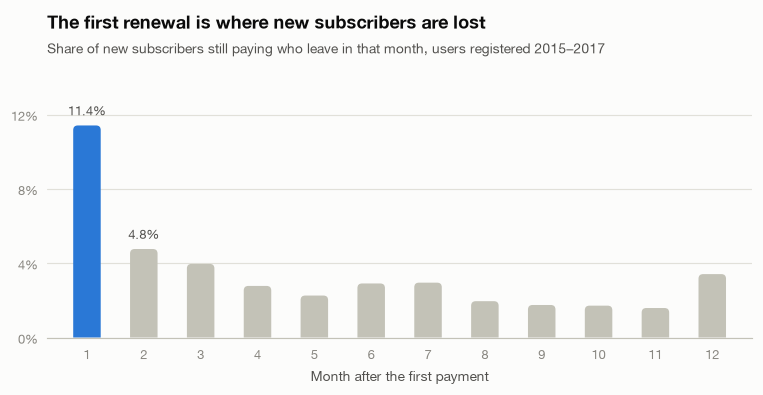

In [7]:
fig, ax = charts.figure(height=3.6)
ax.set_xlim(0.3, 12.7)
ax.set_ylim(0, 13)
colors = [charts.BLUE] + [charts.GRAY] * 11
charts.bars(ax, hazard.index, hazard.values, colors)
charts.note(ax, 1, hazard.iloc[0] + 0.4, f"{hazard.iloc[0]:.1f}%", ha="center", va="bottom")
charts.note(ax, 2, hazard.iloc[1] + 0.4, f"{hazard.iloc[1]:.1f}%", ha="center", va="bottom")
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month after the first payment")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.yaxis.set_major_locator(mticker.MultipleLocator(4))
charts.titles(fig, ax, "The first renewal is where new subscribers are lost",
              "Share of new subscribers still paying who leave in that month, users registered 2015–2017")
charts.save(fig, "01_first_renewal.png")

PosixPath('/Users/artemzadvoryanskiy/Documents/portfolio/kkbox-subscription-analytics/docs/img/01_first_plan_survival.png')

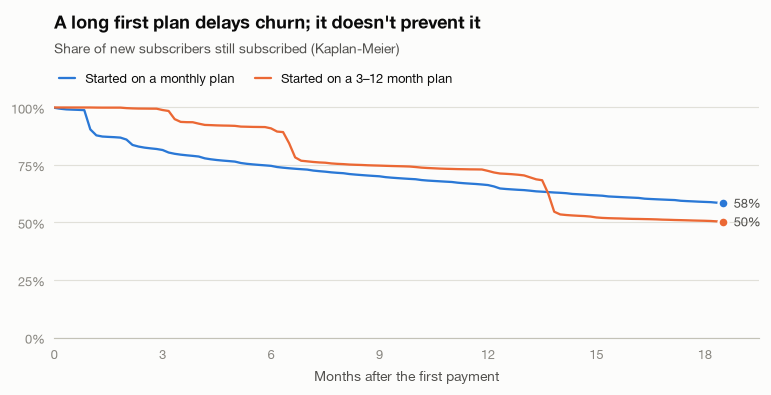

In [8]:
fig, ax = charts.figure(height=3.6)
ax.set_xlim(0, 19.5)
ax.set_ylim(0, 105)
days = range(0, 18 * 30 + 16, 5)
for name, color in [("monthly first plan", charts.BLUE), ("3-12 month first plan", charts.ORANGE)]:
    ys = [100 * survival_at(curves[name], d) for d in days]
    xs = [d / 30 for d in days]
    charts.line(ax, xs, ys, color, name)
    charts.note(ax, xs[-1] + 0.3, ys[-1], f"{ys[-1]:.0f}%")
ax.set_xticks([0, 3, 6, 9, 12, 15, 18])
ax.set_xlabel("Months after the first payment")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.yaxis.set_major_locator(mticker.MultipleLocator(25))
handles = ax.get_lines()
charts.legend(ax, [(handles[0], "Started on a monthly plan"), (handles[2], "Started on a 3–12 month plan")])
charts.titles(fig, ax, "A long first plan delays churn; it doesn't prevent it",
              "Share of new subscribers still subscribed (Kaplan-Meier)")
charts.save(fig, "01_first_plan_survival.png")

**What it says.** Free trials convert in single digits, and the few who convert
churn faster than people who paid from day one. For everyone, the first renewal is
the big drop; after month 3 the monthly loss settles at 2–3%. A long first plan
holds people through its own length and then loses them faster, ending below the
monthly plan by month 18.